In [ ]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np

from tfgans import utils

In [2]:
import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [3]:
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = np.expand_dims(x_train, axis=-1)
# summarize the shape of the dataset
print('Train', x_train.shape)

Train (60000, 28, 28, 1)


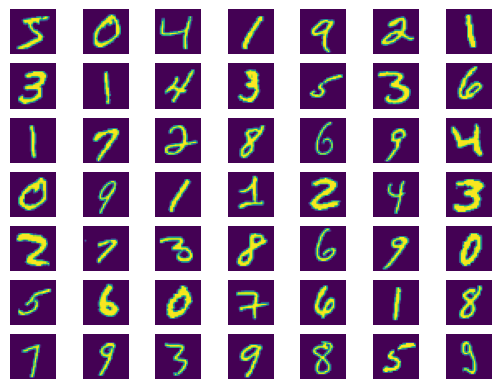

In [4]:
for i in range(49):
    # define subplot
    plt.subplot(7, 7, 1 + i)
    # turn off axis
    plt.axis('off')
    # plot raw pixel data
    plt.imshow(x_train[i])
plt.show()

In [5]:
# data scaling 
x_train = utils.scale_data(x_train)

In [ ]:
from tfgans import models
# input shape
img_shape = x_train.shape[1:]
# size of the latent space
latent_dim = 100
# create the discriminator
discriminator = models.build_discriminator(input_shape=img_shape)
# create the generator
generator = models.build_generator(latent_dim, init_dim=7, final_dim=28, n_channel=1)
# create the gan
gan_model = models.build_gan(generator, discriminator)
# train model
models.train_gan(generator, discriminator, gan_model, x_train, latent_dim, epochs=500, batch_size=256, summary_interval=100)

In [7]:
from keras.models import load_model
model = load_model('path to your saved model gen_after_xxx.h5')

In [18]:
latent_points = utils.generate_latent_points(100, 49)  #Latent dim and n_samples
# generate images
X = model.predict(latent_points)
# scale from [-1,1] to [0,1]
X = (X + 1) / 2.0


2/2 [==============================] - 0s 176ms/step


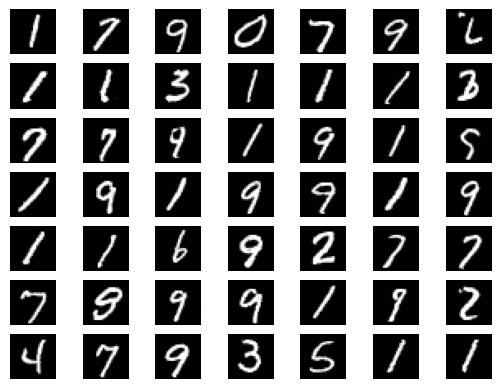

In [19]:
for i in range(49):
    # define subplot
    plt.subplot(7, 7, 1 + i)
    # turn off axis
    plt.axis('off')
    # plot raw pixel data
    plt.imshow(X[i], cmap='gray')
plt.show()